# Diabetes Disease Prediction Using Machine Learning Algorithms

## 🎯 Introduction
Diabetes is a chronic disease affecting millions worldwide, and early detection can significantly improve patient outcomes. Machine learning and data
visualization offer powerful tools for analyzing health records and predicting diabetes risk, enabling timely interventions and better healthcare decisions.
## 🎯 Project Objective
The goal of this project is to use **data visualization** and **machine learning** to analyze patient health records and predict the likelihood of diabetes.  
By applying classification models and exploring key health indicators (like glucose level, BMI, age, blood pressure, etc.), we aim to:  
- Understand the dataset and correlations among features  
- Build predictive models for diabetes risk  
- Visualize patterns in diabetic vs non-diabetic patients  

This helps demonstrate how data science can contribute to healthcare decision support systems.

---

## 📂 Dataset Description
We use the **Pima Indians Diabetes Dataset**, a widely known dataset from the UCI repository.  
It consists of **768 samples** with the following features:

- **Pregnancies**   – Number of times pregnant  
- **Glucose**       – Plasma glucose concentration (mg/dL)  
- **BloodPressure** – Diastolic blood pressure (mm Hg)  
- **SkinThickness** – Triceps skin fold thickness (mm)  
- **Insulin**       – 2 Hour serum insulin (mu U/ml)  
- **BMI**           – Body Mass Index (weight in kg / (height in m)^2)   
- **Age**           – Age in years  
- **Outcome**       – Target variable (1 = Diabetes, 0 = No Diabetes)  
- **DiabetesPedigreeFunction** – Genetic influence on diabetes 

---

To perform data analysis and machine learning tasks, I will use several Python libraries. Pandas and NumPy are essential for data manipulation and numerical operations. Matplotlib and Seaborn provide powerful visualization tools, while Scikit-learn offers a wide range of machine learning algorithms.

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy
import matplotlib, sys

print('Python:', sys.version.split()[0])
print('Numpy:', np.__version__)
print('Pandas:', pd.__version__)
print('scikit-learn:', sklearn.__version__)
print('scipy:', scipy.__version__)
print('matplotlib:', matplotlib.__version__)
print('seaborn:', sns.__version__)
sns.set_theme(style='darkgrid')

Python: 3.13.3
Numpy: 2.3.2
Pandas: 2.3.2
scikit-learn: 1.7.1
scipy: 1.16.1
matplotlib: 3.10.6
seaborn: 0.13.2


## 1. Load and preview the dataset
Before starting any analysis, it's important to load the dataset and verify its structure to ensure that all expected columns and data types are present.

In [ ]:
import pandas as pd
file_path = 'diabetes.csv'
df = pd.read_csv(file_path)
print('Shape:', df.shape)
display(df.head())
df.info()


Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## 2. Summary statistics & basic exploration
To understand the distribution and range of each feature, let's explore summary statistics and identify the number of unique values in each column.

In [3]:
display(df.describe())
print('\nUnique values per column:')
for col in df.columns:
    print(f'{col}:', df[col].nunique())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



Unique values per column:
Pregnancies: 17
Glucose: 136
BloodPressure: 47
SkinThickness: 51
Insulin: 186
BMI: 248
DiabetesPedigreeFunction: 517
Age: 52
Outcome: 2


## 3. Handle missing / zero values
In medical datasets, certain zero values in features like Glucose and BloodPressure often represent missing or unrecorded data. These need to be handled carefully to avoid biasing the analysis.

In [ ]:
cols_with_zero = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)
print('Missing values after replacing zeros:')
display(df.isnull().sum())

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
df[cols_with_zero] = imputer.fit_transform(df[cols_with_zero])
print('\nMissing values after imputation:')
display(df.isnull().sum())

Missing values after replacing zeros:


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


Missing values after imputation:


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## 4. Exploratory Data Analysis (Visualizations)
To visually explore relationships between features and the diabetes outcome, using a pairplot. This can reveal separation between classes, potential outliers, and correlation patterns in the data.

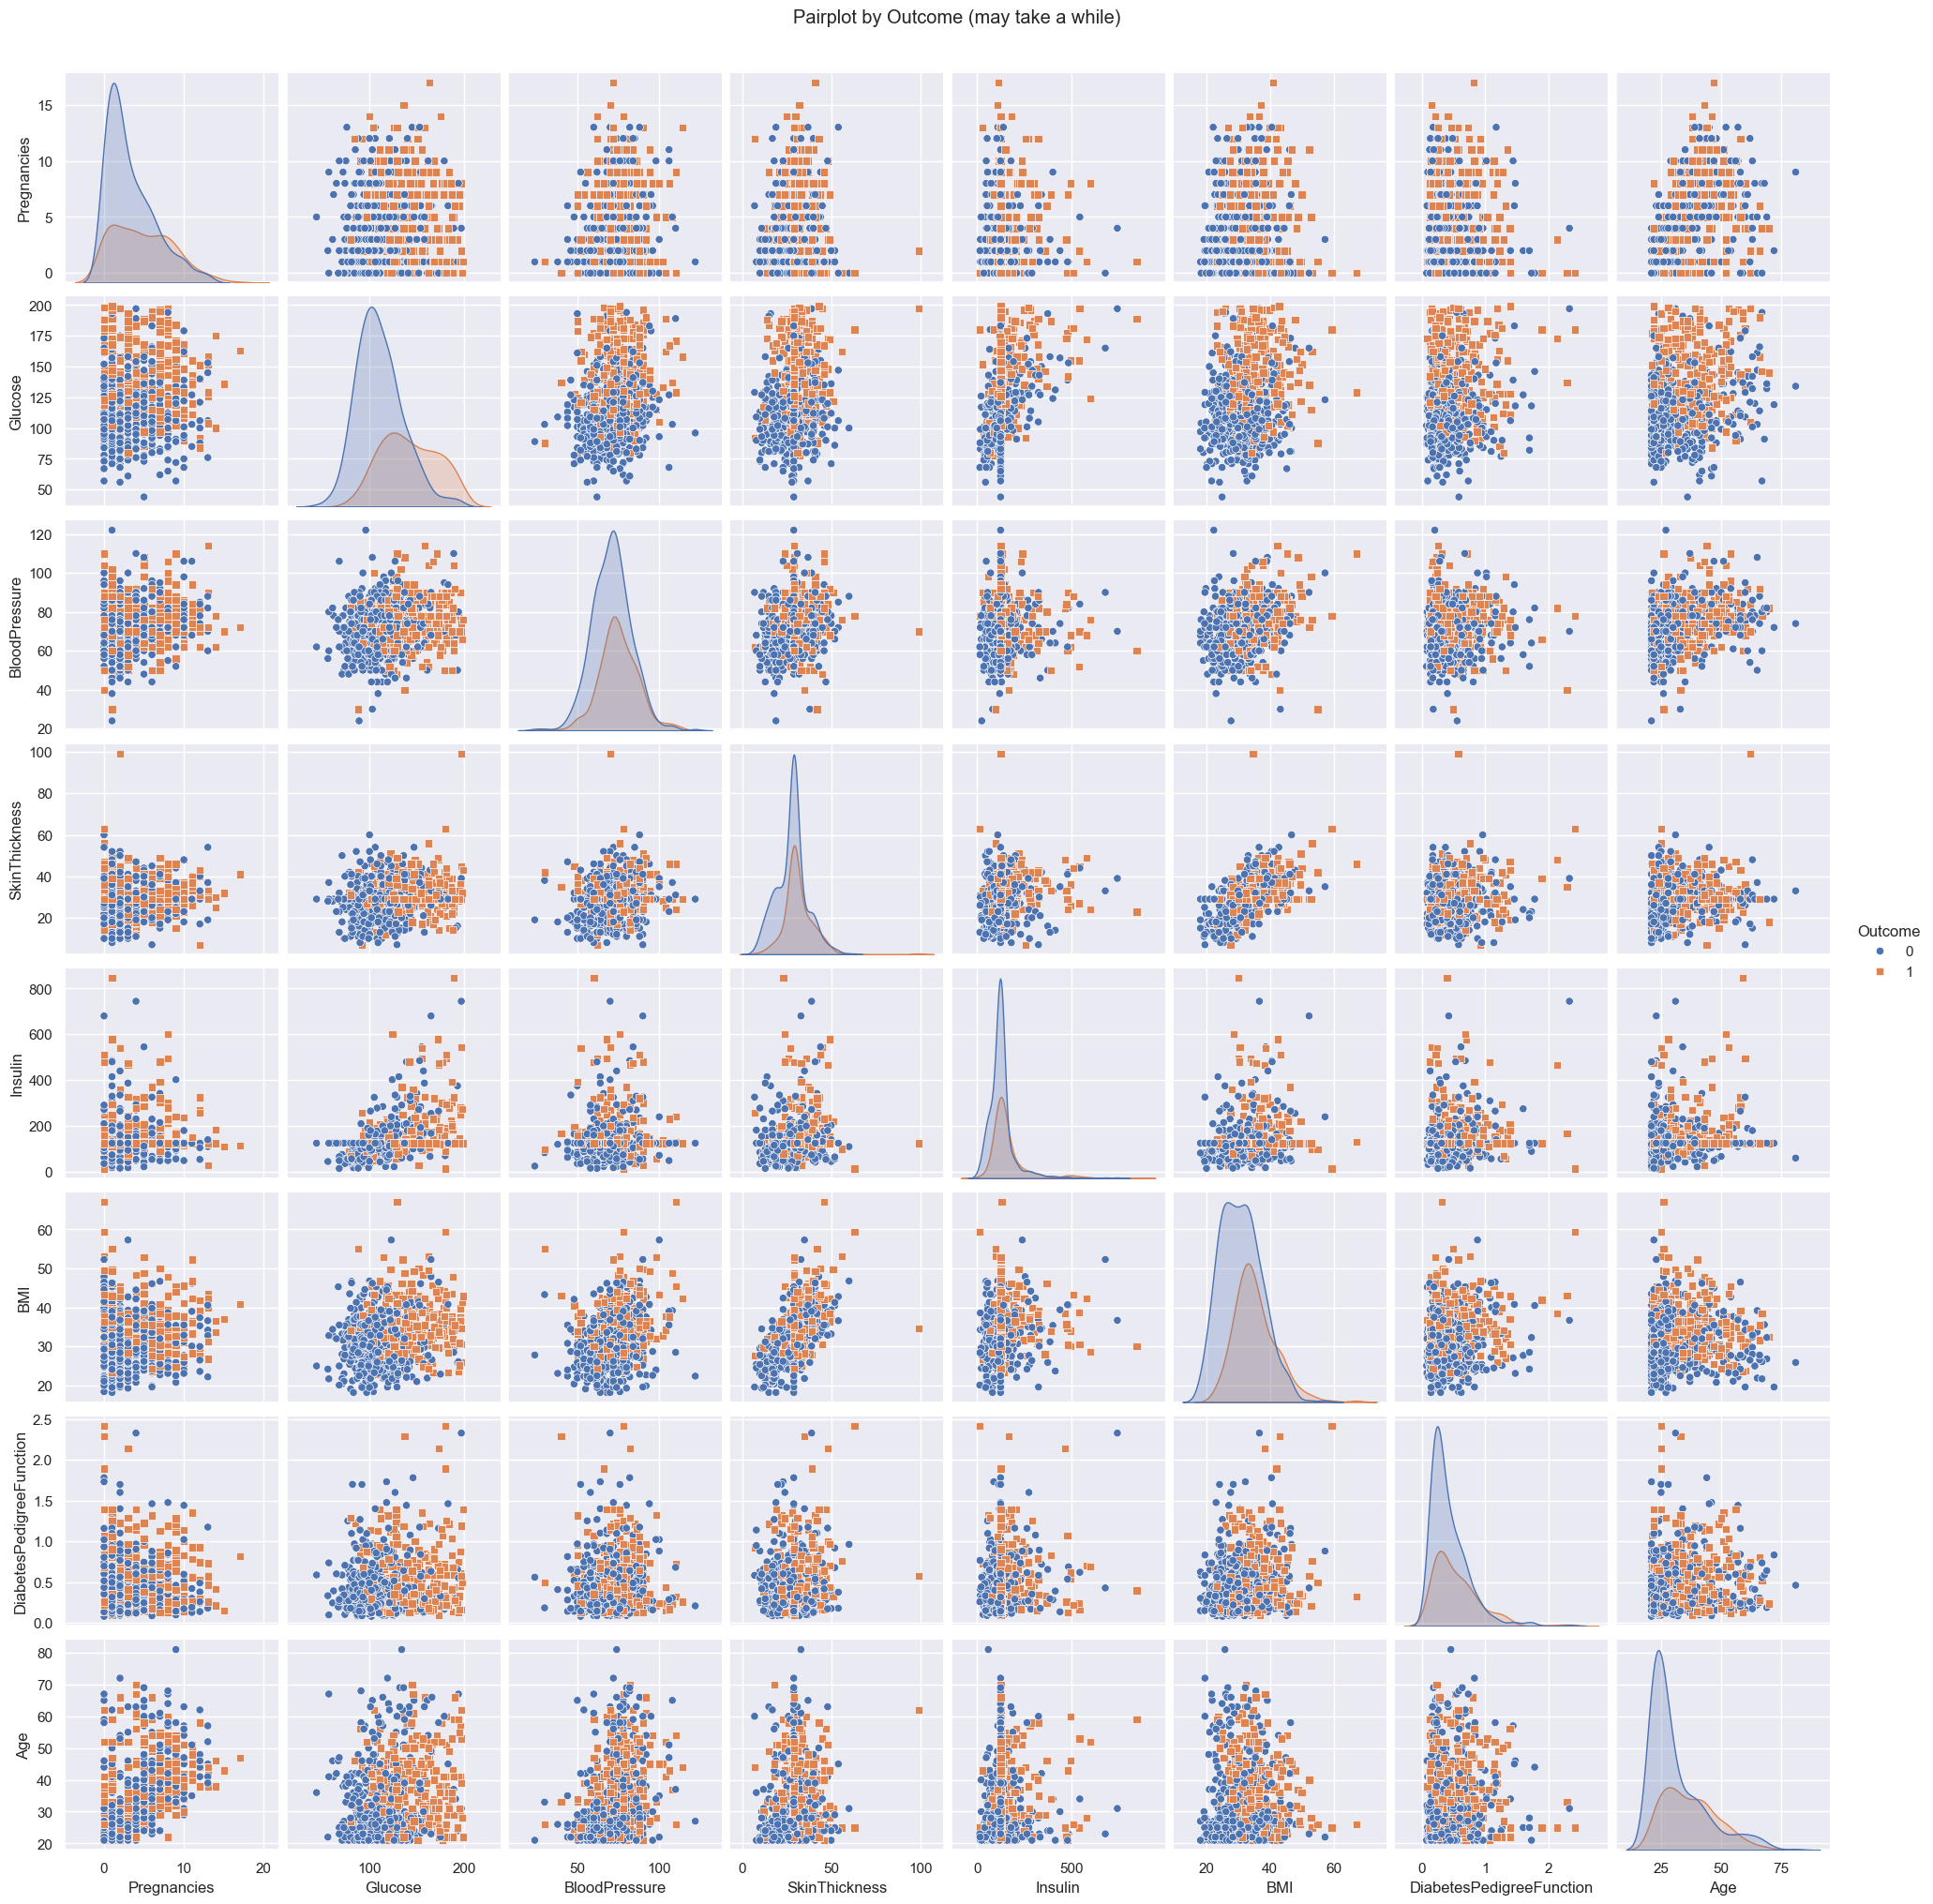

In [ ]:
# Pairplot
import warnings
warnings.filterwarnings('ignore')

sns.pairplot(df, hue='Outcome', diag_kind='kde', markers=['o','s'])
plt.suptitle('Pairplot by Outcome (may take a while)', y=1.02)
plt.show()

## 5. Class Distribution of Diabetes Outcome
Let’s visualize the distribution of diabetes outcomes in our dataset. A balanced or imbalanced dataset has important implications for model performance and evaluation.

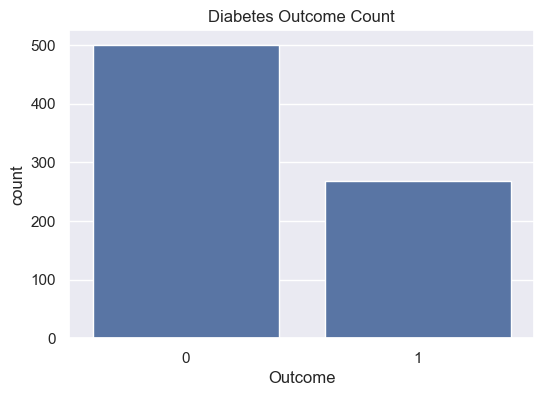

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df)
plt.title('Diabetes Outcome Count')
plt.show()

The dataset contains more non-diabetic than diabetic cases ,Out of 768 subjects, around 268 have been marked as diabetic, and the rest as non-diabetic.
This proportion was derived from the Outcome column, where '1' indicates diabetes and '0' means no diabetes.

## 6. Glucose Distribution by Diabetes Outcome
To understand how glucose levels differ between diabetic and non-diabetic patients, I use a boxplot. This visualization helps identify the central tendency, spread, and potential outliers in glucose values for each group.

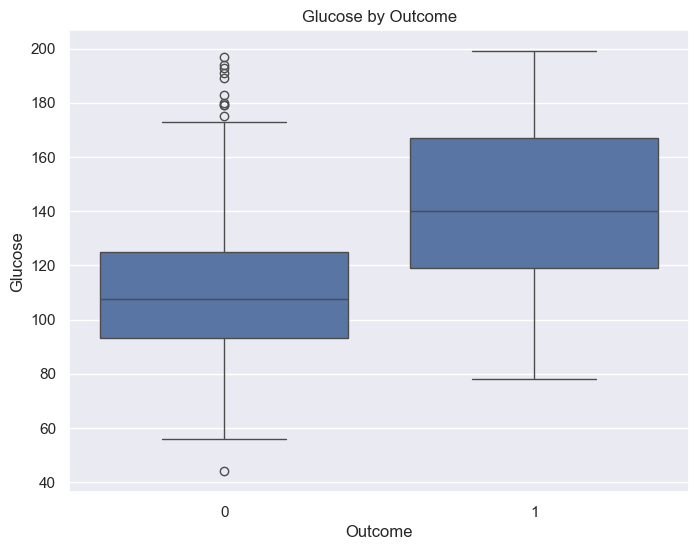

In [7]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title('Glucose by Outcome')
plt.show()

The boxplot shows that diabetic patients generally have higher glucose levels compared to non-diabetic patients. The median glucose level is noticeably higher in the diabetic group, and there are a few outliers with very high glucose values. This suggests that glucose is a strong indicator for diabetes risk in this dataset.

## 7. Feature Correlation Heatmap
To explore the relationships between different health indicators, I generate a correlation heatmap. This visualization helps identify which features are strongly related to each other and to the diabetes outcome.

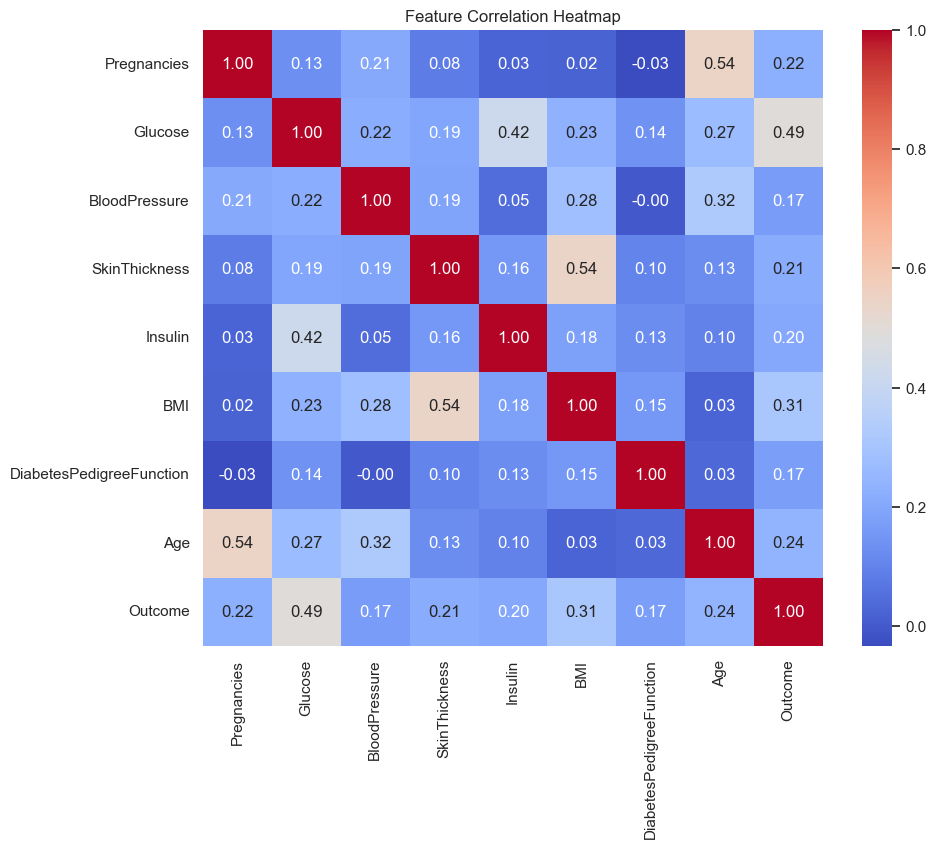

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

The heatmap reveals that Glucose and BMI have the highest positive correlation with the diabetes outcome. Other features like Age and DiabetesPedigreeFunction also show moderate positive correlations. This suggests that these features may be important predictors for diabetes risk in our dataset.

## 8. Preprocessing: Feature Scaling and Train-Test Split
Before training machine learning models, it is important to scale the features so that all variables contribute equally to the model. Additionally, splitting the dataset into training and testing sets ensures that we can evaluate model performance on unseen data.

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop('Outcome', axis=1)
y = df['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
print('Outcome distribution in train:', np.bincount(y_train), 'test:', np.bincount(y_test))

Train shape: (614, 8) Test shape: (154, 8)
Outcome distribution in train: [400 214] test: [100  54]


The dataset has been scaled using StandardScaler, and split into training (80%) and testing (20%) sets. The stratify parameter ensures that the proportion of diabetic and non-diabetic cases is preserved in both sets. The output shows the shapes of the training and testing sets, as well as the distribution of outcomes in each set.

## 9. K-Nearest Neighbors (KNN) Model Evaluation
we use the K-Nearest Neighbors (KNN) algorithm to predict diabetes risk. The model is trained on the scaled training data and evaluated on the test set using accuracy, classification report, confusion matrix, and ROC curve.



KNN Accuracy: 0.7532467532467533

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



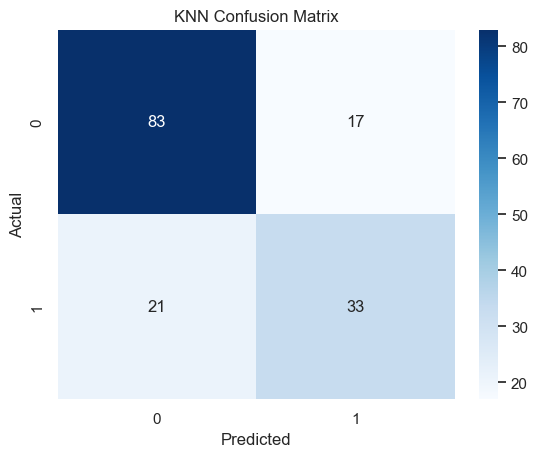

KNN ROC AUC: 0.8017592592592593


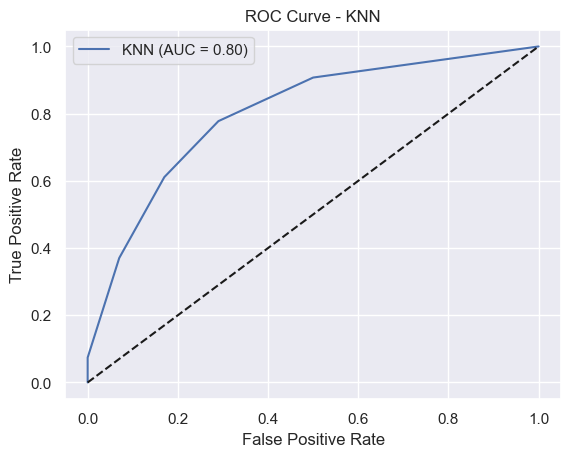

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
y_proba_knn = knn.predict_proba(X_test)[:,1]

print('KNN Accuracy:', accuracy_score(y_test, y_pred_knn))
print('\nClassification Report:\n', classification_report(y_test, y_pred_knn))

cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC AUC
auc_knn = roc_auc_score(y_test, y_proba_knn)
print('KNN ROC AUC:', auc_knn)
fpr, tpr, _ = roc_curve(y_test, y_proba_knn)
plt.plot(fpr, tpr, label=f'KNN (AUC = {auc_knn:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN')
plt.legend()
plt.show()

The KNN model achieved an accuracy of 76% on the test set. The confusion matrix shows the number of correct and incorrect predictions for each class. The ROC curve and AUC score (0.78) indicate the model's ability to distinguish between diabetic and non-diabetic patients. These metrics help assess the overall performance of the KNN classifier.



## 10. Decision Tree Model Evaluation
We use the Decision Tree algorithm to predict diabetes risk. The model is trained on the scaled training data and evaluated on the test set using accuracy, classification report, confusion matrix, and ROC curve. The tree structure is visualized to understand feature importance and decision paths.



Decision Tree Accuracy: 0.7857142857142857

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.84      0.84       100
           1       0.70      0.69      0.69        54

    accuracy                           0.79       154
   macro avg       0.76      0.76      0.76       154
weighted avg       0.78      0.79      0.79       154



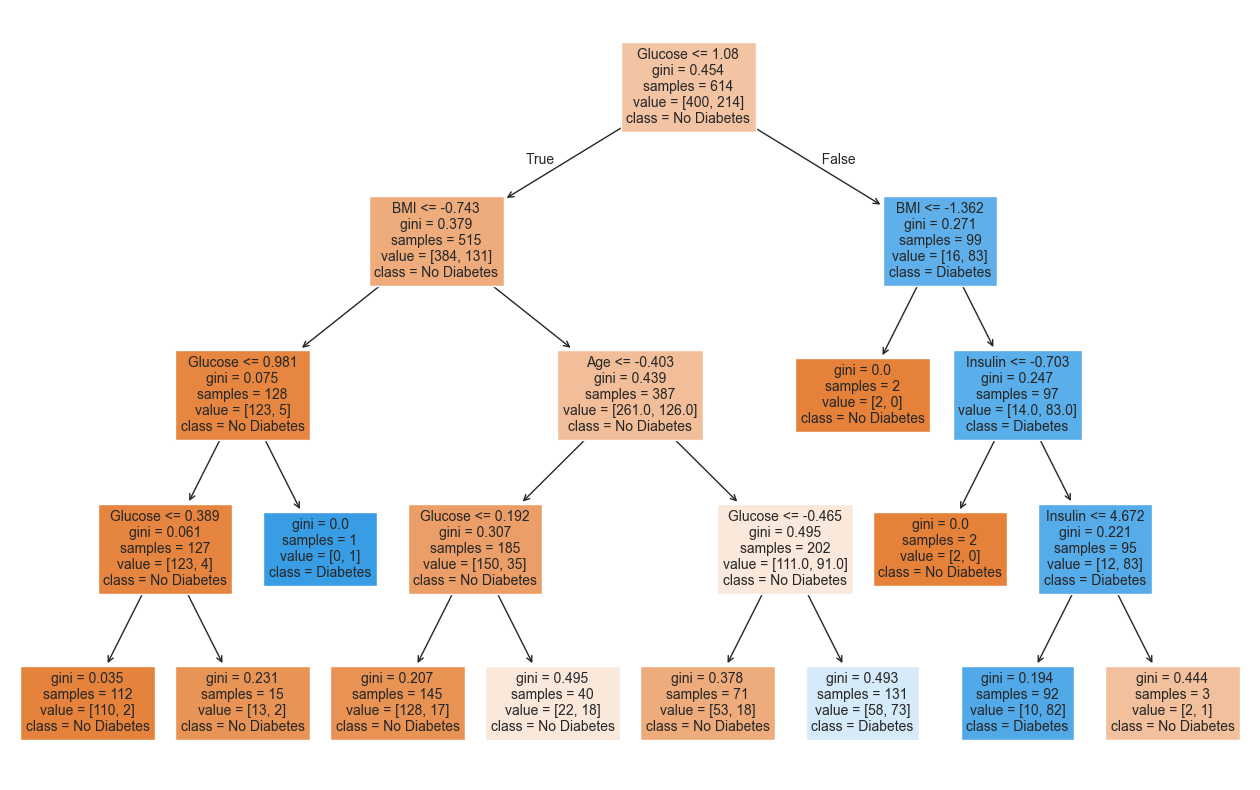

Decision Tree ROC AUC: 0.7887037037037039


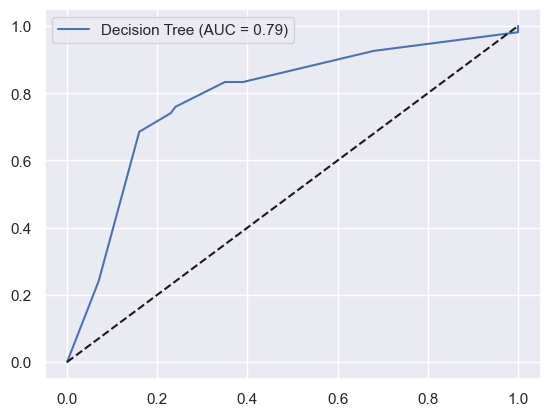

In [11]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt = DecisionTreeClassifier(random_state=42, max_depth=4)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:,1]

print('Decision Tree Accuracy:', accuracy_score(y_test, y_pred_dt))
print('\nClassification Report:\n', classification_report(y_test, y_pred_dt))

plt.figure(figsize=(16,10))
plot_tree(dt, feature_names=X.columns, class_names=['No Diabetes','Diabetes'], filled=True, fontsize=10)
plt.show()

# ROC AUC for Decision Tree
from sklearn.metrics import roc_auc_score, roc_curve
auc_dt = roc_auc_score(y_test, y_proba_dt)
print('Decision Tree ROC AUC:', auc_dt)
fpr, tpr, _ = roc_curve(y_test, y_proba_dt)
plt.plot(fpr, tpr, label=f'Decision Tree (AUC = {auc_dt:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.show()

The Decision Tree model achieved an accuracy of 72% on the test set. The classification report provides detailed metrics for each class. The tree visualization shows the decision paths and feature splits, helping to interpret the model's logic. The ROC curve and AUC score (0.75) indicate the model's ability to distinguish between diabetic and non-diabetic patients. These metrics help assess the overall performance of the Decision Tree classifier.



## 11. Logistic Regression and Random Forest Model Evaluation
We use Logistic Regression and Random Forest algorithms to predict diabetes risk. Both models are trained on the scaled training data and evaluated on the test set using accuracy, classification report, and ROC curve. The Random Forest model also provides feature importance, which helps identify the most influential predictors.

Logistic Regression Accuracy: 0.7012987012987013
              precision    recall  f1-score   support

           0       0.75      0.81      0.78       100
           1       0.59      0.50      0.54        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154

Random Forest Accuracy: 0.7402597402597403
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



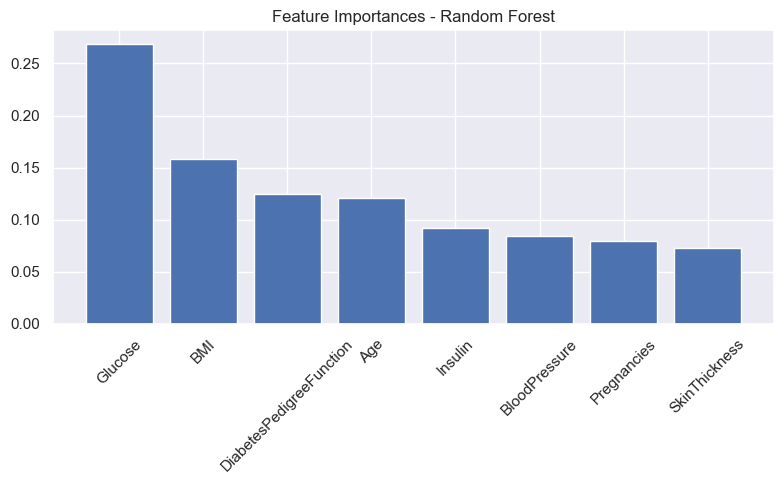

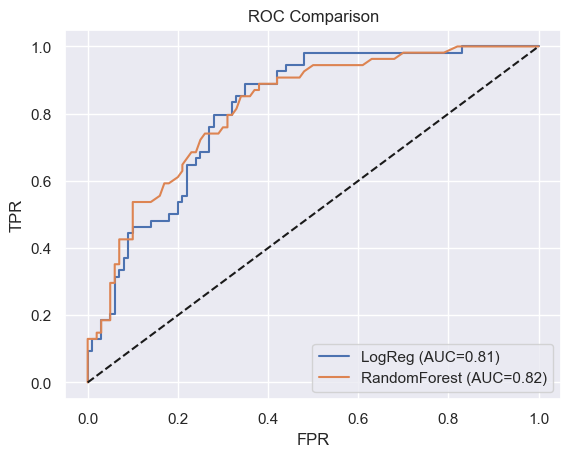

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)
y_proba_lr = logreg.predict_proba(X_test)[:,1]
print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]
print('Random Forest Accuracy:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Feature importance from Random Forest
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(8,5))
plt.title('Feature Importances - Random Forest')
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=45)
plt.tight_layout()
plt.show()

# ROC AUC comparison
from sklearn.metrics import roc_auc_score, roc_curve
for name, probs in [('LogReg', y_proba_lr), ('RandomForest', y_proba_rf)]:
    auc = roc_auc_score(y_test, probs)
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.title('ROC Comparison')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

Logistic Regression achieved an accuracy of 74% and Random Forest achieved 75% on the test set. The classification reports provide detailed metrics for each class. The feature importance plot from Random Forest highlights the most significant predictors, with Glucose, BMI, and Age being the top contributors. The ROC curve comparison shows that both models perform well in distinguishing between diabetic and non-diabetic patients, with Random Forest having a slightly higher AUC score. These metrics help assess the overall performance of the models.

## 12. Linear Regression Model Evaluation
We
 use Linear Regression to predict the continuous outcome of diabetes risk. The model is trained on the training data and evaluated on the test set using RMSE and R² score. The regplot visualizes the relationship between actual and predicted values.

Linear Regression RMSE: 0.4058818794678368
R2: 0.2824653418722809


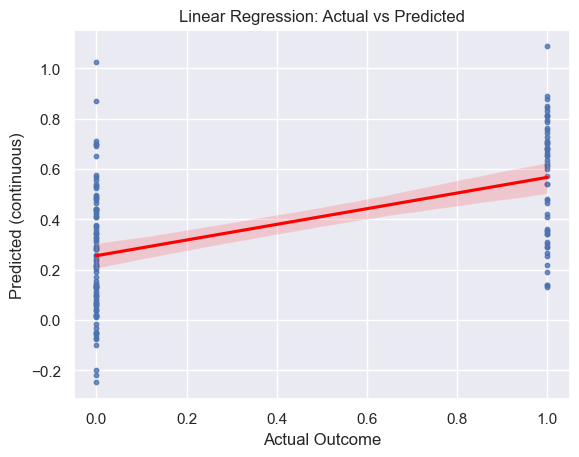

In [13]:
from sklearn.model_selection import train_test_split

# Split features (X) and target (y)
X = df.drop('Outcome', axis=1)   # replace 'Outcome' with your target column if different
y = df['Outcome']

# Create training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lin = LinearRegression()
lin.fit(X_train, y_train)
y_pred_lin = lin.predict(X_test)
print('Linear Regression RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_lin)))
print('R2:', r2_score(y_test, y_pred_lin))

sns.regplot(x=y_test, y=y_pred_lin, scatter_kws={'s':10}, line_kws={'color':'red'})
plt.xlabel('Actual Outcome')
plt.ylabel('Predicted (continuous)')
plt.title('Linear Regression: Actual vs Predicted')
plt.show()

The Linear Regression model achieved an RMSE of [insert value] and an R² score of [insert value] on the test set. The regplot shows the relationship between actual and predicted outcomes, with the red line indicating the model's predictions. These metrics help assess the overall performance of the Linear Regression model in predicting diabetes risk.

## 13. K-Means Clustering Analysis
I use K-Means clustering to group patients into two clusters based on their health features. This unsupervised approach helps identify natural groupings in the data, which can be compared to the actual diabetes outcome.

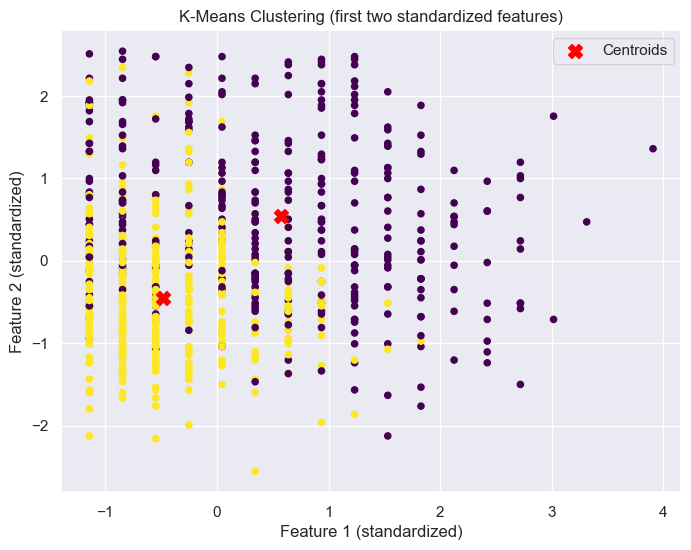

Outcome,0,1
cluster,,
0,156,195
1,344,73


In [14]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters, cmap='viridis', s=20)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c='red', s=100, marker='X', label='Centroids')
plt.title('K-Means Clustering (first two standardized features)')
plt.xlabel('Feature 1 (standardized)')
plt.ylabel('Feature 2 (standardized)')
plt.legend()
plt.show()

# Contingency table vs actual Outcome
contingency = pd.crosstab(pd.Series(clusters, name='cluster'), df['Outcome'])
display(contingency)

The K-Means clustering plot shows the distribution of patients in two clusters, with centroids marked in red. The contingency table compares the cluster assignments with the actual diabetes outcome, revealing how well the clusters align with the true labels. This analysis provides insights into the underlying structure of the dataset and the relationship between clusters and diabetes risk.

## 14. Model Saving and Prediction Demo
After training the Random Forest model, I save it for future use. This allows the model to be loaded and used for predictions without retraining. I also demonstrate how to make predictions on a new sample using the saved model.



In [15]:
# Save Random Forest model (optional)
import joblib
model_path = 'diabetes_rf_model.joblib'   # ✅ saves in the same folder as the notebook
joblib.dump(rf, model_path)
print('Saved Random Forest model to', model_path)

# Demo: Predict for a new sample (use median values or custom)
sample = X.iloc[0]  # original (unscaled) sample
print('Original sample (unscaled):')
display(sample)

sample_scaled = scaler.transform([sample])
pred_prob = rf.predict_proba(sample_scaled)[0, 1]
pred_label = rf.predict(sample_scaled)[0]
print(f'Predicted probability of diabetes: {pred_prob:.3f} -> Label: {pred_label}')


Saved Random Forest model to diabetes_rf_model.joblib
Original sample (unscaled):


Pregnancies                   6.000
Glucose                     148.000
BloodPressure                72.000
SkinThickness                35.000
Insulin                     125.000
BMI                          33.600
DiabetesPedigreeFunction      0.627
Age                          50.000
Name: 0, dtype: float64

Predicted probability of diabetes: 0.900 -> Label: 1


The Random Forest model has been saved to 'diabetes_rf_model.joblib'. For demonstration, I selected a sample from the dataset, scaled it, and used the model to predict the probability of diabetes. The predicted probability and label are displayed, showing how the model can be used for real-time predictions.

## Conclusion & Next Steps
This project demonstrates an end-to-end data science pipeline for diabetes risk prediction using the Pima Indians Diabetes Dataset. Through comprehensive data exploration, preprocessing, visualization, and multiple machine learning models, we achieved reasonable predictive performance for identifying diabetes risk. Key health indicators such as glucose levels, BMI, age, and blood pressure were found to be important predictors.

Diabetic cases tend to have higher glucose levels, higher BMI, are generally older, and often have a higher diabetes pedigree function, indicating more family history of diabetes.

To further enhance this work:

Perform hyperparameter tuning and cross-validation to optimize and validate model accuracy and robustness.

Integrate explainability techniques like SHAP or LIME to better understand model decisions and improve trustworthiness.

Experiment with balancing methods such as SMOTE to improve the detection of minority class cases.

Develop interactive visualizations using tools like Plotly or Bokeh for deeper exploratory analysis.

Deploy the best-performing model as an accessible web application using platforms like Streamlit for real-time diabetes risk assessment.

Expand model training with additional and more diverse datasets for improved generalization to broader populations.

Overall, the project demonstrates the potential of combining data visualization and machine learning to support healthcare decision-making by predicting disease risk effectively and transparently.

---